Part 4: Data Visualisation

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Load data
df = pd.read_csv("MY Stock Market 2000-01-03 .csv")
df["Date"] = pd.to_datetime(df["Date"])
df.dropna(how='all', inplace=True)

Simple Line Plot to show how the closing price change overtime


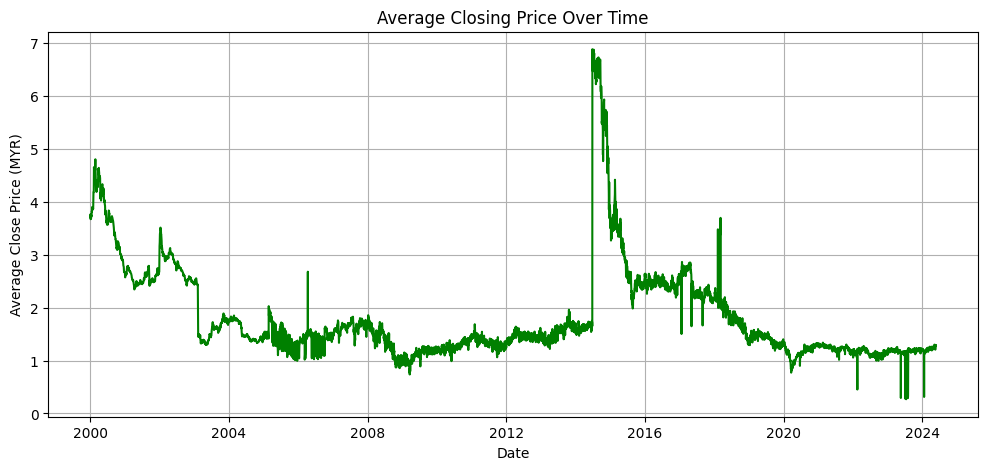

In [38]:

# Simple Line Plot: Overall Market Trend (Average Close Price Over Time)
df_market_trend = df.groupby("Date")["Close"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_market_trend, x="Date", y="Close", color="green")
plt.title("Average Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Close Price (MYR)")
plt.grid(True)
plt.show()


Top 5 fastest growing companies with Line Plot

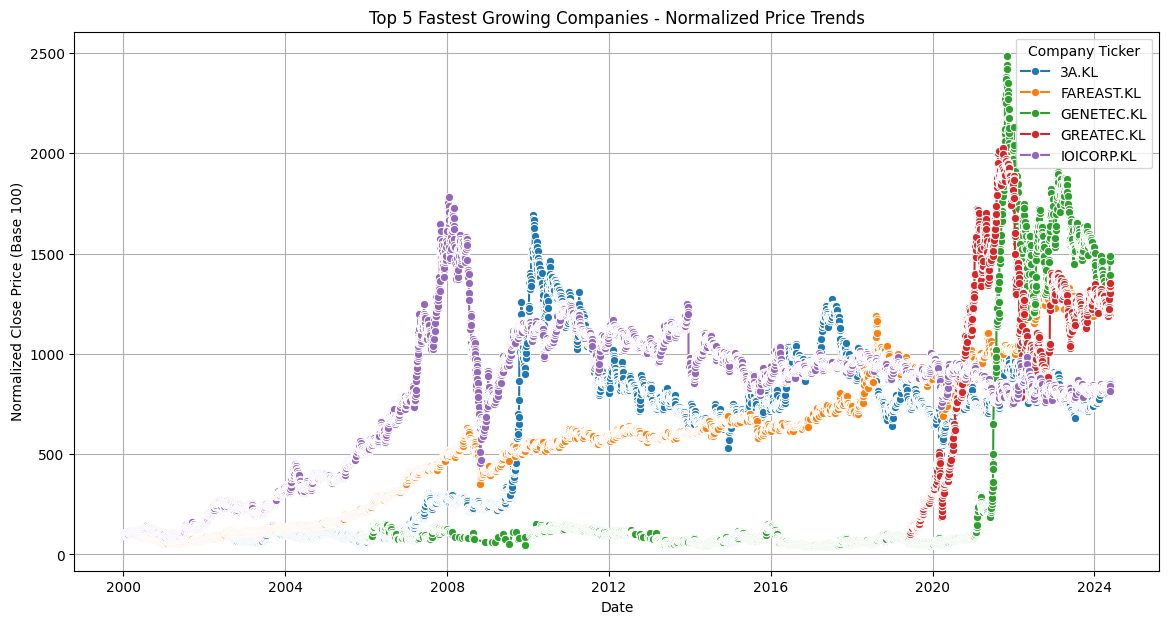

In [39]:
# Drop rows with NaN Close prices
df = df.dropna(subset=["Close"])

# Convert Close & Volume to numeric
df["Close"] = pd.to_numeric(df["Close"])
df["Volume"] = pd.to_numeric(df["Volume"])

# Find first and last closing price for each company
price_change = df.groupby("Ticker").agg(
    first_price=("Close", "first"),
    last_price=("Close", "last")
)

# Calculate percentage growth
price_change["growth_percentage"] = (price_change["last_price"] - price_change["first_price"]) / price_change["first_price"] * 100

# Get the top 5 fastest-growing companies
top_growing_companies = price_change.nlargest(5, "growth_percentage").index.tolist()

# Filter dataset for only the top-growing companies
df_top = df[df["Ticker"].isin(top_growing_companies)].copy()  # Use .copy() to avoid SettingWithCopyWarning

# Normalize prices to start at 100 for better comparison
df_top.loc[:, "Normalized_Close"] = df_top.groupby("Ticker")["Close"].transform(lambda x: (x / x.iloc[0]) * 100)

# Plot multi-line chart with normalized prices
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_top, x="Date", y="Normalized_Close", hue="Ticker", marker="o")

# Customize the chart
plt.title("Top 5 Fastest Growing Companies - Normalized Price Trends")
plt.xlabel("Date")
plt.ylabel("Normalized Close Price (Base 100)")
plt.legend(title="Company Ticker")
plt.grid(True)

# Show the plot
plt.show()


- Top 10 Companies based on growth percentages
- Top 10 Companies based on average trading volume

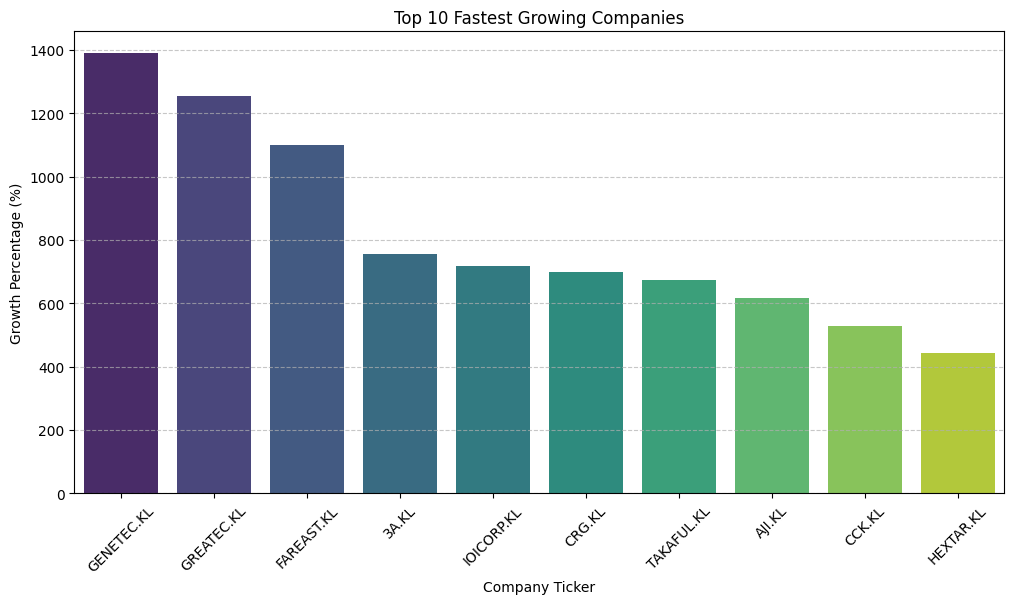

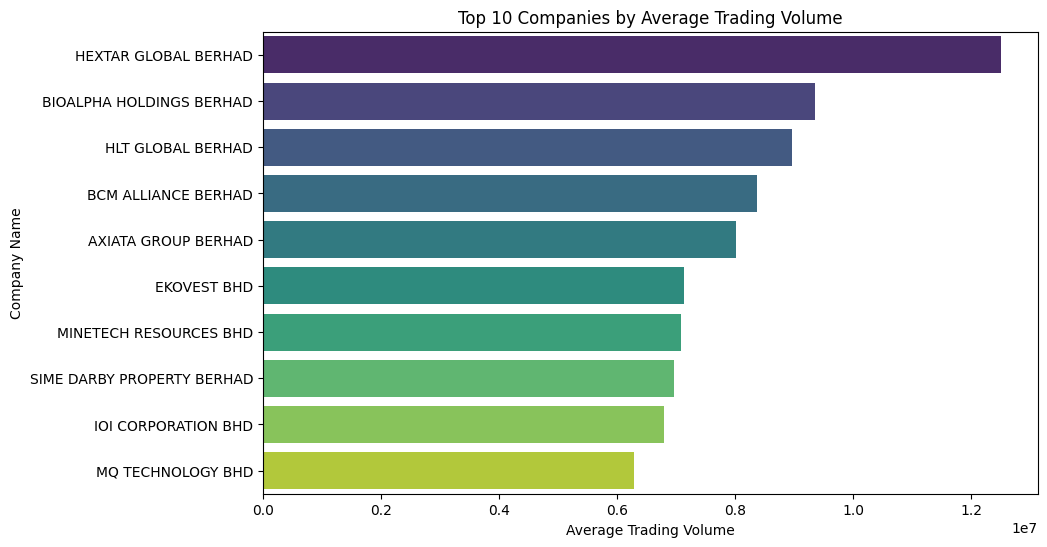

In [40]:
# Bar Chart: Growth Percentages of Top 10 Companies
top_growth = price_change.nlargest(10, "growth_percentage").reset_index()
top_growth.columns = ["Ticker", "First Price", "Last Price", "Growth Percentage"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_growth, x="Ticker", y="Growth Percentage", hue="Ticker", palette="viridis", legend=False)
plt.title("Top 10 Fastest Growing Companies")
plt.xlabel("Company Ticker")
plt.ylabel("Growth Percentage (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

top_companies = df.groupby("Company_Name")["Volume"].mean().nlargest(10).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_companies.values, y=top_companies.index, hue=top_companies.index, palette="viridis", legend=False)
plt.xlabel("Average Trading Volume")
plt.ylabel("Company Name")
plt.title("Top 10 Companies by Average Trading Volume")
plt.show()




The Largest Company (Trading Volume)

In [41]:
df["Volume"] = pd.to_numeric(df["Volume"])

# Find the company with the highest average trading volume
largest_company_by_volume = df.groupby("Ticker")["Volume"].mean().idxmax()
highest_avg_volume = df.groupby("Ticker")["Volume"].mean().max()

print(f"Largest Company by Trading Volume: {largest_company_by_volume} with {highest_avg_volume:.2f} average volume")

Largest Company by Trading Volume: HEXTAR.KL with 12503013.55 average volume


Fast Growing Company

In [42]:
price_change = df.groupby("Ticker").agg(
    first_price=("Close", "first"),
    last_price=("Close", "last")
)

# Calculate percentage change
price_change["growth_percentage"] = (price_change["last_price"] - price_change["first_price"]) / price_change["first_price"] * 100

# Identify the fastest-growing company
fastest_growing_company = price_change["growth_percentage"].idxmax()
highest_growth = price_change["growth_percentage"].max()

print(f"Fastest Growing Company: {fastest_growing_company} with {highest_growth:.2f}% growth")

Fastest Growing Company: GENETEC.KL with 1388.51% growth


Highest Traded Stock

In [43]:
# Find the company with the highest total trading volume
largest_company_total_volume = df.groupby("Ticker")["Volume"].sum().idxmax()
highest_total_volume = df.groupby("Ticker")["Volume"].sum().max()

print(f"Most Actively Traded Stock: {largest_company_total_volume} with {highest_total_volume:.2f} total volume")


Most Actively Traded Stock: EKOVEST.KL with 41357217076.00 total volume


Correlation Heatmap 

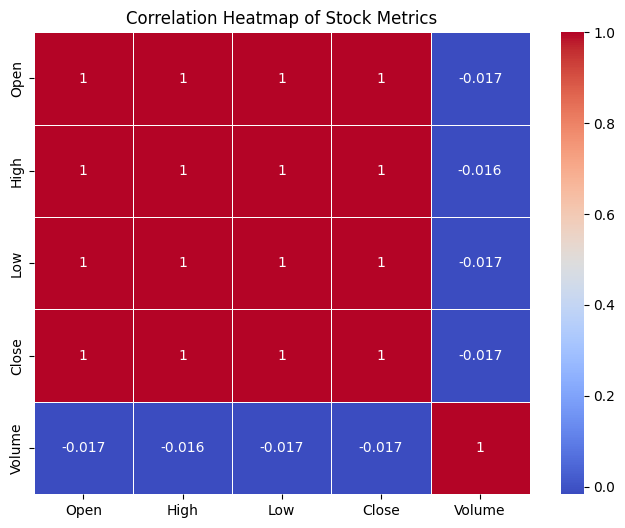

In [44]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[["Open", "High", "Low", "Close", "Volume"]].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Stock Metrics")
plt.show()

Detailed Analysis on Genetec KL

In [45]:
stock_ticker = "GENETEC.KL"
df_stock = df[df["Ticker"] == stock_ticker].sort_values("Date")

The histograms below illustrate the distribution of the stock's closing price and trading volume:  

- **Close Price Distribution**:  
  - The distribution is **right-skewed**, indicating that lower closing prices occur more frequently, while higher prices are less common.  
  - There are **multiple peaks**, suggesting the stock may have traded in distinct price ranges over time.  

- **Trading Volume Distribution**:  
  - The distribution is **highly right-skewed**, meaning that most trading days have **low volume**, with occasional days of extreme trading activity.  
  - The presence of **long tails** suggests rare but significant volume spikes.  

These insights highlight that the stock typically trades at lower prices and volumes, with occasional surges in both metrics.

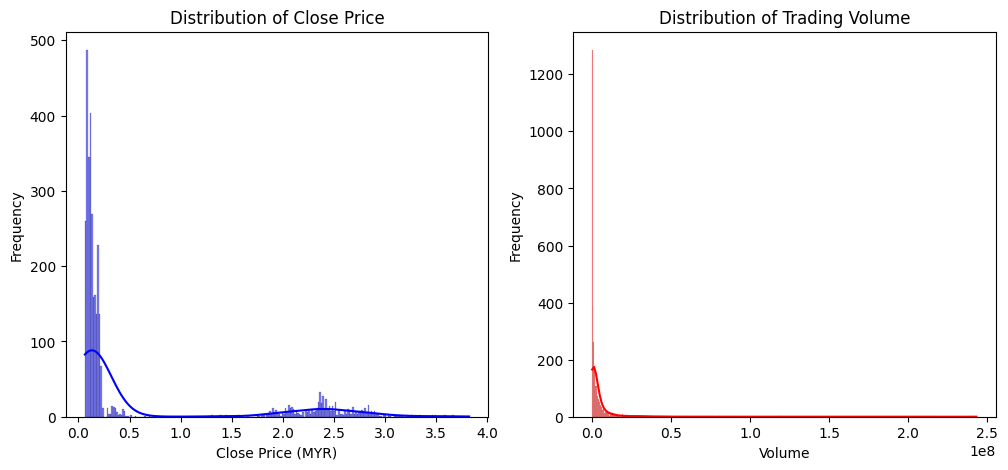

In [ ]:
# Histograms for Close Price and Volume

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_stock["Close"], kde=True, color="blue")
plt.title("Distribution of Close Price")
plt.xlabel("Close Price (MYR)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(df_stock["Volume"], kde=True, color="red")
plt.title("Distribution of Trading Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()  


The box plots below provide insights into the spread and outliers in the data:

- **Close Price Box Plot**:  
  - The interquartile range (IQR) is relatively tight, indicating that most closing prices are within a narrow range.  
  - There are **numerous outliers on the higher end**, suggesting occasional spikes in the stock's closing price.  

- **Trading Volume Box Plot**:  
  - Most trading volumes are concentrated in a small range, as shown by the compact box.  
  - There are **significant outliers on the higher end**, indicating days with unusually high trading activity.  

These insights highlight the presence of volatility in both price and volume, with trading volume showing extreme fluctuations on certain days.

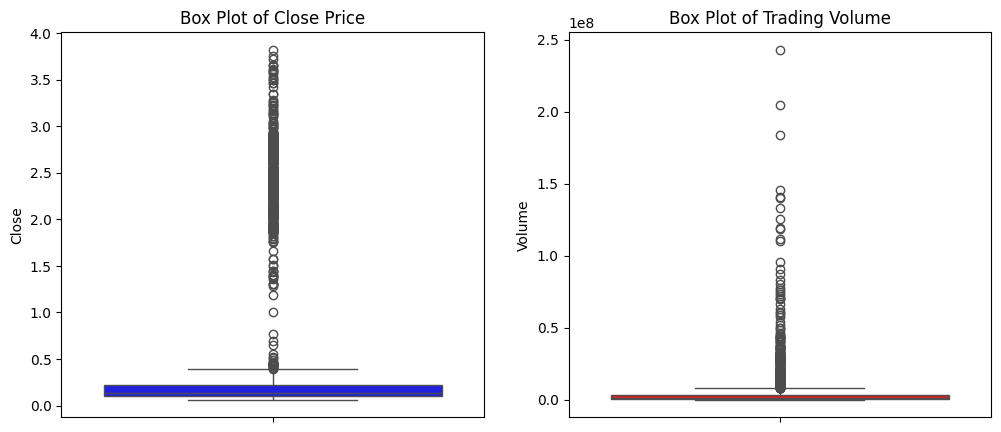

In [47]:
# Box Plots for Close Price and Volume
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_stock["Close"], color="blue")
plt.title("Box Plot of Close Price")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_stock["Volume"], color="red")
plt.title("Box Plot of Trading Volume")
plt.show()


The scatter plot below explores the relationship between trading volume and closing price:  

- There is **no clear linear relationship** between trading volume and closing price, suggesting that higher trading volume does not necessarily lead to significant price changes.  
- The majority of data points are concentrated at lower trading volumes, with prices clustering around two distinct levels.  
- A few extreme outliers exist at **high trading volumes**, but they do not appear to strongly impact the stock's closing price.  

This suggests that factors other than just volume may be influencing price movements.

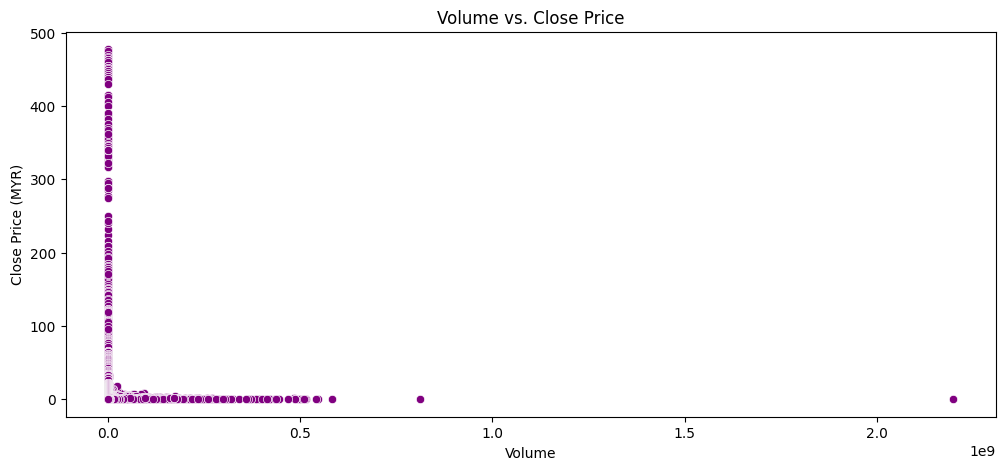

In [ ]:
# Scatter Plot: Volume vs. Close Price
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x="Volume", y="Close", color="purple")
plt.title("Volume vs. Close Price")
plt.xlabel("Volume")
plt.ylabel("Close Price (MYR)")
plt.show()


The bar chart above shows the average trading volume by month.
- There is no clear seasonal trend

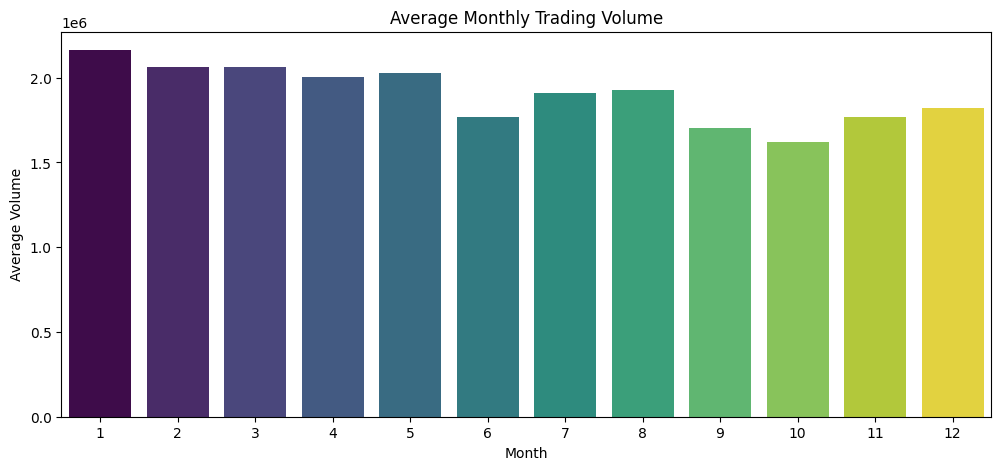

In [49]:
# Bar Chart: Average Monthly Volume
df["Month"] = df["Date"].dt.month
monthly_volume = df.groupby("Month")["Volume"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=monthly_volume, x="Month", y="Volume", hue="Month", palette="viridis", legend=False)
plt.title("Average Monthly Trading Volume")
plt.xlabel("Month")
plt.ylabel("Average Volume")
plt.show()

The scatter plot explores the relationship between trading volume and price changes.

- The plot shows **no strong or consistent correlation** between trading volume and price changes. This suggests that large price changes are not systematically associated with high trading volume.
- In some cases, high volume may coincide with significant price movements, but the lack of a clear pattern indicates that volume alone is not a reliable predictor of price changes.

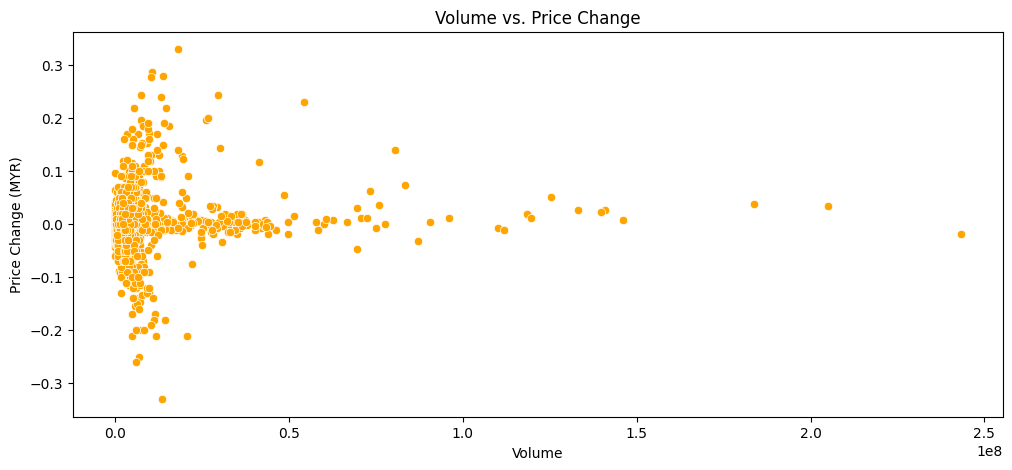

In [50]:
# Volume vs. Price Change
df_stock["Price_Change"] = df_stock["Close"].diff()
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_stock, x="Volume", y="Price_Change", color="orange")
plt.title("Volume vs. Price Change")
plt.xlabel("Volume")
plt.ylabel("Price Change (MYR)")
plt.show()
